# 🔢 MNIST Digit Recognizer

## 0. Introduction

### 0.1 Overview
The MNIST data can be used to learn **computer vision fundamentals and deep learning foundations**. Such foundations will be presented in this notebook by **exploring the accuracy & performance of a MLP and CNN** on this famous dataset, and its ability to perform **multiclass classification among 10 different digits.** 

The highest accuracy will be found by applying hyperparameter tuning - testing different batch sizes and number of hidden layers - and best practices will be applied throughout the notebook such as early stopping, model checkpointing, and learning rate scheduling.

### 🎯 0.2 Objectives
* Create a deep MLP Model
* Create a CNN Model
* Optimize different hyperparamters for both types of models 
* Pick the best model and observe its performance on the data.
* Visualize sample predictions: Present its capabilities on samples of the data

### 0.3 Project Context

MNIST ("Modified National Institute of Standards and Technology") dataset contains imagery of handwritten digits and is a well-known dataset for practicing classification and computer vision. In fact it is known as "the de facto “hello world” dataset of computer vision."

Project Source: [Dataset from Kaggle](https://www.kaggle.com/competitions/digit-recognizer)

### 0.4 Key Findings
* From classification with Logistic Regression to Deep Learning, neural networks display an advantageous gap in performance.
* Tuning hyperparamaters was always beneficial for the neural networks' accuracy.
* All models' final validation scores are:
    1. **Tuned CNN - 0.9942**
    2. CNN Baseline - 0.9850
    3. Tuned MLP - 0.9805
    4. Base MLP - 0.9663
    5. Log Regression - 0.9137
* 🏆️ The best model is a tuned CNN model reaching 99.4% accuracy on the test set

### 0.5 Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import pytorch_lightning as pl
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.serialization
import torchvision
import torchmetrics
from lightning.pytorch.utilities.model_summary import ModelSummary
from pytorch_lightning.callbacks import (
    ModelCheckpoint,
)
from pytorch_lightning.loggers import CSVLogger
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.optim import SGD, Adam, AdamW, RMSprop
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau, StepLR
from torch.utils.data import DataLoader, TensorDataset
from utils.helper import objective, plot_csv_logger, run
from utils.models import *
import logging
import warnings

logging.getLogger("lightning").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", message=".*LeafSpec.*deprecated.*")

pl.seed_everything(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.serialization.add_safe_globals(
    [
        torch.nn.modules.batchnorm.BatchNorm1d,
        torch.nn.modules.batchnorm.BatchNorm2d,
    ]
)
optuna.logging.set_verbosity(optuna.logging.WARNING)

torch.set_float32_matmul_precision("high")

sns.set_palette(["lightseagreen", "darkorange"])


print(f"PyTorch: {torch.__version__}")
print(f"Lightning: {pl.__version__}")

print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

W0824 15:47:41.064000 22068 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
Seed set to 42


PyTorch: 2.13.0+cu132
Lightning: 2.6.5
GPU Available: True
GPU: NVIDIA GeForce RTX 5070 Laptop GPU


## 1. Data Preparation

### 1.0 Loading Data

In [2]:
df = pd.read_csv("dataset/train.csv")
print(f"Raw dataset shape: {df.shape}")
df.head()

Raw dataset shape: (42000, 785)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### 1.1 Splitting the data

Note: Neural networks can train more reliably with small input values (0 - 1) than large values (current 0 - 255 pixel range). With this in mind, we will divide each pixel by `/ 255.0`  to to have small input values of `0-1` instead of `0-255`

In [3]:
X = df.drop("label", axis=1).values.astype(np.float32) / 255.0
y = df["label"].values.astype(np.int64)

#### Splitting the data (60 / 20 / 20)
Considering that hypertuning will be performed, a validation set will be useful:
* Train set: 60%
* Validation set: 20%
* Test set: 20%

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

for name, arr in [("Train", X_train), ("Val", X_val), ("Test", X_test)]:
    print(f"{name}: {arr.shape[0]} samples ({arr.shape[0]/len(X)*100:.1f}%)")

Train: 25200 samples (60.0%)
Val: 8400 samples (20.0%)
Test: 8400 samples (20.0%)


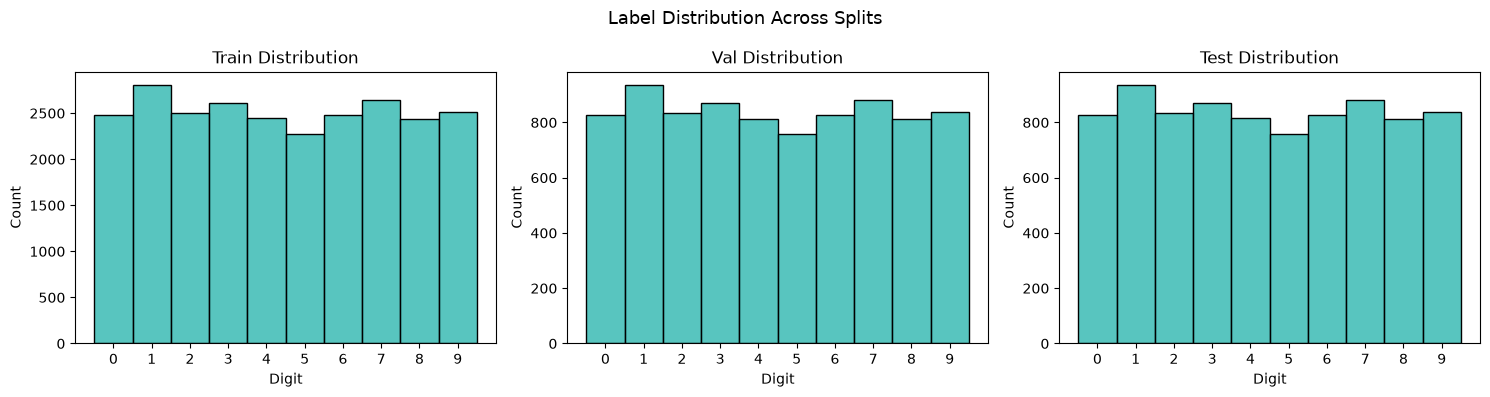

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (split_name, split_y) in zip(
    axes, [("Train", y_train), ("Val", y_val), ("Test", y_test)]
):
    sns.histplot(split_y, bins=10, ax=ax, discrete=True)
    ax.set_title(f"{split_name} Distribution")
    ax.set_xlabel("Digit")
    ax.set_ylabel("Count")
    ax.set_xticks(range(10))

plt.suptitle("Label Distribution Across Splits", fontsize=13)
plt.tight_layout()
plt.show()

Distributions between all 3 splits can be seen above and there seem to be no anomalic differences between them - they are all identical in distribution.

Minibatch splits for Neural Networks: DataModule and DataLoaders

This project utilizes a DataModule with Lightning to handle calling dataloaders. Found in `utils/models.py`

In [6]:
splits = {
    "X_train": X_train,
    "y_train": y_train,
    "X_val": X_val,
    "y_val": y_val,
    "X_test": X_test,
    "y_test": y_test,
}

dm = DigitDataModule(**splits, batch_size=256)
x_batch, y_batch = next(iter(dm.train_dataloader()))
print(f"Batch X shape: {x_batch.shape}")
print(f"Batch y shape: {y_batch.shape}")

Batch X shape: torch.Size([256, 784])
Batch y shape: torch.Size([256])


### 1.1 Data Integrity Checks

#### 1.1.1 Null or Duplicate values:

In [7]:
for split_name, split_X, split_y in [
    ("Train", X_train, y_train),
    ("Val", X_val, y_val),
    ("Test", X_test, y_test),
]:
    df_split = pd.DataFrame(split_X)
    nulls = df_split.isnull().sum().sum()
    duplicates = df_split.duplicated().sum()
    print(f"{split_name} nulls: {nulls} | Duplicates: {duplicates}")

Train nulls: 0 | Duplicates: 0
Val nulls: 0 | Duplicates: 0
Test nulls: 0 | Duplicates: 0


✅ No nulls or duplicates across the sets

#### 1.1.2 Invalid data:
Possible data corruptions / edge cases to check:
* Pixels out of range
* All black pixels
* All white pixels
* Images with only one unique pixel value

In [8]:
out_of_range = ((X_train < 0) | (X_train > 1)).sum()
print(f"Pixels out of range [0,1]: {out_of_range}")

all_black = (X_train.sum(axis=1) == 0).sum()
print(f"All black images: {all_black}")

all_white = (X_train.sum(axis=1) == 784).sum()
print(f"All white images: {all_white}")

single_value = np.array([len(np.unique(row)) == 1 for row in X_train]).sum()
print(f"Single value images: {single_value}")

Pixels out of range [0,1]: 0
All black images: 0
All white images: 0
Single value images: 0


✅ No corruptions detected

### 📊 1.2 Data Overview / EDA

In [9]:
df_train = pd.DataFrame(X_train)
print(df_train.shape)

(25200, 784)


In [10]:
print(df_train.info())

<class 'pandas.DataFrame'>
RangeIndex: 25200 entries, 0 to 25199
Columns: 784 entries, 0 to 783
dtypes: float32(784)
memory usage: 75.4 MB
None


In [11]:
print(df_train.describe())

           0        1        2        3        4        5        6        7    \
count  25200.0  25200.0  25200.0  25200.0  25200.0  25200.0  25200.0  25200.0   
mean       0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
std        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
min        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
25%        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
50%        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
75%        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
max        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   

           8        9    ...           774           775           776  \
count  25200.0  25200.0  ...  25200.000000  25200.000000  25200.000000   
mean       0.0      0.0  ...      0.000880      0.000471      0.000199   
std        0.0      0.0  ...      0.025797      

* Data is presented in pixel values 
* Each of the 784 columns is one pixel
* Presence of a number indicates pixels, and its value tells us how bright the pixel is. 

What does the data look like?

In [12]:
X_train[0][:20]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.], dtype=float32)

* Data is presented in pixel values as above ^
* and views as a digit as below:

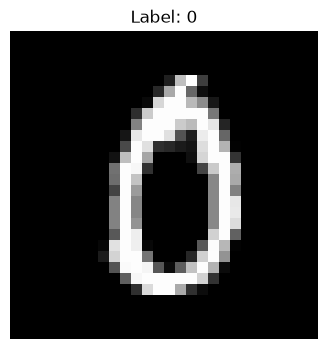

In [13]:
plt.figure(figsize=(4, 4))
plt.imshow(X_train[0].reshape(28, 28), cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

Sample visuals

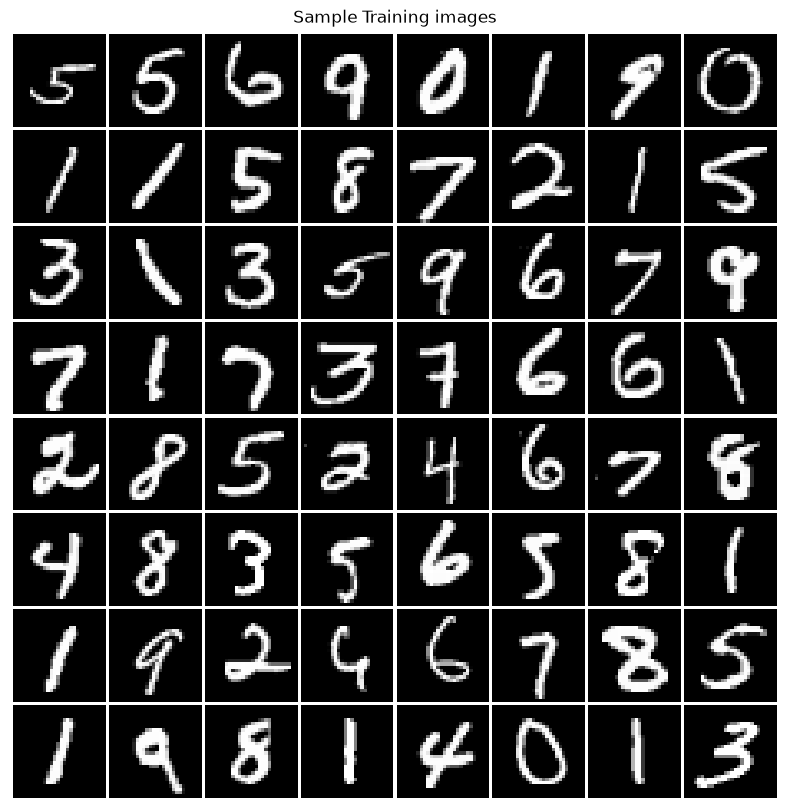

In [14]:
plt.figure(figsize=(10, 10))
plt.axis("off")
plt.title("Sample Training images")
plt.imshow(
    np.transpose(
        torchvision.utils.make_grid(
            x_batch[:64].reshape(64, 1, 28, 28),
            nrow=8,
            padding=1,
            pad_value=1.0,
            normalize=True,
        ),
        (1, 2, 0),
    ),
    cmap="gray",
)
plt.show()

## 2. Model Building
We will be testing 3 types of models, 2 of which will be untuned and tuned, making 5 models:
1. Baseline Logistic Regression
2. MLP (Base)
3. MLP (tuned)
4. CNN (base)
5. CNN (tuned)

The main training run loop (found in `helper.py`) has early stopping and checkpoints in place.

### 2.0 Logistic Regression

Baseline model

In [15]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
print(f"Logistic Regression val_acc : {lr.score(X_val, y_val):.4f}")
scores = {}
scores["Log Regression"] = round(lr.score(X_val, y_val), 4)

Logistic Regression val_acc : 0.9142


Starting with **0.91** as our performance baseline

### 2.1 Multilayer Perceptron Model (MLP)
1. Base MLP
2. Tuned MLP

#### 2.1.1 Base MLP

Base MLP with default configs according to PyTorch docs:

In [16]:
baseline_config = {
    "hidden_layers": [128],
    "activation": "relu",
    "dropout": 0.0,
    "optimizer": "adamw",
    "lr": 1e-3,
    "loss_fn": "cross_entropy",
    "norm_layer": None,
    "batch_size": 256,
}

trainer, model, dm = run(
    baseline_config,
    splits,
    epochs=50,
    progress=True,
    log=True,
    name="base_mlp",
    num_workers=15,
)
base_mlp_log_dir = trainer.logger.log_dir
checkpoint_cb = next(cb for cb in trainer.callbacks if isinstance(cb, ModelCheckpoint))
base_mlp_score = float(checkpoint_cb.best_model_score)
scores["Base MLP"] = round(base_mlp_score, 4)
print("Baseline val_acc:", round(base_mlp_score, 4))

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
c:\Users\giddy\Desktop\Turing\computer-vision-mnist\.venv\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Users\giddy\Desktop\Turing\computer-vision-mnist\checkpoints\base_mlp exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\giddy\Desktop\Turing\computer-vision-mnist\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:429: Consider setting `persistent_workers=True` in 'val_dataloader' to speed up the dataloader worker initialization.
c:\Users\giddy\Desktop\Turing\computer-vision-mnist\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:429: Consider setting `persistent_workers=True` in 'train_dataloader' to speed up the dataloader worker initialization.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Baseline val_acc: 0.9657


The MLP model with default parameters **achieved ~0.9663 accuracy**, already a much noticeable improvement from our baseline 0.91 score from Logistic Regression.

#### 2.1.2 Tuned MLP

> Make sure to test different optimizers, batch sizes, activation functions, learning rates, dropout ratios, hidden layer architectures, loss functions.

Hypertuning with Optuna was performed on the data. To save time, the best params were saved into a dictionary, `best_params` found below, and called instead of running the Optuna function and trials again.

*If the user wishes to run tuning again, simply uncomment the following block:*

In [17]:
# sampler = optuna.samplers.TPESampler(seed=42)
# mlp_study = optuna.create_study(direction="maximize")
# mlp_study.optimize(
#     lambda trial: objective(trial, splits, model_type="mlp"),
#     n_trials=20,
#     show_progress_bar=True,
# )
# print("MLP best val_acc:", mlp_study.best_value)
# print("MLP best params: ", mlp_study.best_params)
# best_params = mlp_study.best_params

*Direct results from above tuning code:*
* *MLP best val_acc: 0.9794047474861145*
* *MLP best params:  {'hidden_layers': '[1024, 512, 256]', 'activation': 'gelu', 'norm_layer': 'BatchNorm1d', 'optimizer': 'adamw', 'lr': 0.00016686784775895715, 'weight_decay': 7.687032421799726e-05, 'dropout': 0.24019027316662447, 'loss_fn': 'label_smoothing', 'batch_size': 128}*


In [18]:
best_params = {
    "hidden_layers": "[1024, 512, 256]",
    "activation": "gelu",
    "norm_layer": "BatchNorm1d",
    "optimizer": "adamw",
    "lr": 0.00016686784775895715,
    "weight_decay": 7.687032421799726e-05,
    "dropout": 0.24019027316662447,
    "loss_fn": "label_smoothing",
    "batch_size": 128,
}

In [19]:
best_params["hidden_layers"] = (
    eval(best_params["hidden_layers"])
    if isinstance(best_params["hidden_layers"], str)
    else best_params["hidden_layers"]
)

mlp_tuned_trainer, mlp_tuned_model, mlp_tuned_dm = run(
    best_params,
    splits,
    epochs=50,
    progress=True,
    log=True,
    name="tuned_mlp",
    model_type="mlp",
    num_workers=15,
)
tuned_mlp_log_dir = mlp_tuned_trainer.logger.log_dir
checkpoint_cb = next(
    cb for cb in mlp_tuned_trainer.callbacks if isinstance(cb, ModelCheckpoint)
)
tuned_mlp_score = float(checkpoint_cb.best_model_score)
scores["Tuned MLP"] = round(tuned_mlp_score, 4)
print("Tuned val_acc:", round(tuned_mlp_score, 4))

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
c:\Users\giddy\Desktop\Turing\computer-vision-mnist\.venv\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Users\giddy\Desktop\Turing\computer-vision-mnist\checkpoints\tuned_mlp exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Tuned val_acc: 0.9807


* Tuned MLP achieves a remarkable score of 0.9805 / 98% accuracy
* Tuning is beneficial for the model with more than +0.01 improvement

Training Curves: Base vs. Tuned

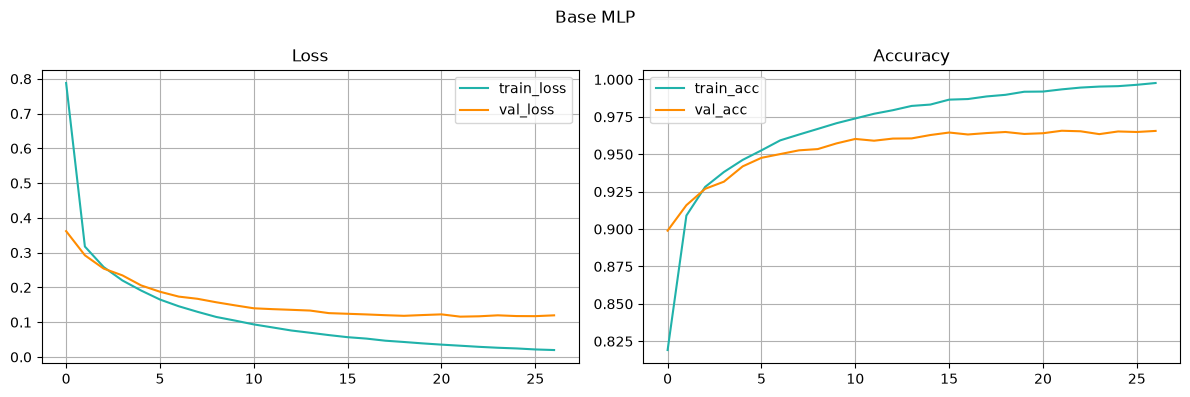

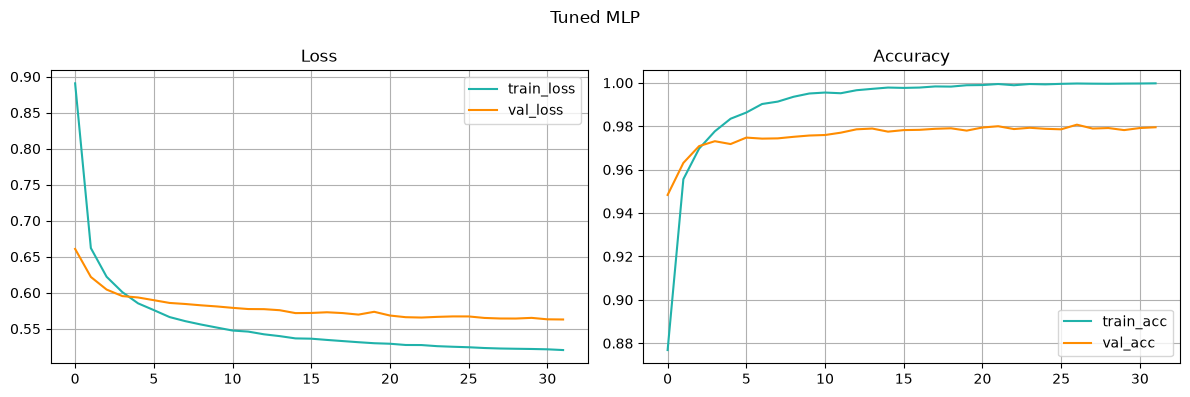

In [20]:
plot_csv_logger(f"{base_mlp_log_dir}/metrics.csv", "Base MLP")
plot_csv_logger(f"{tuned_mlp_log_dir}/metrics.csv", "Tuned MLP")

* Tuning increases loss , possibly due to some **regularization** parameters that were applied. This may help with generalization but give higher loss values with prevention and more caution. 
* Overall accuracy has improved when tuned, reaching definitively higher numbers in accuracy, staying along that high bar, and achieving this earlier.

### 2.2 CNN Model
#### 2.2.1 Base CNN

Running CNN Model with default general params:

In [21]:
cnn_baseline_config = {
    "out_channels": [32, 64],
    "lr": 1e-3,
    "dropout": 0.0,
    "optimizer": "adam",
    "loss_fn": "cross_entropy",
    "norm_layer": None,
    "batch_size": 256,
}

cnn_base_trainer, cnn_base_model, cnn_base_dm = run(
    cnn_baseline_config,
    splits,
    epochs=50,
    progress=True,
    log=True,
    name="cnn_baseline",
    model_type="cnn",
    num_workers=15,
)
base_cnn_log_dir = cnn_base_trainer.logger.log_dir
checkpoint_cb = next(
    cb for cb in cnn_base_trainer.callbacks if isinstance(cb, ModelCheckpoint)
)
cnn_baseline_score = float(cnn_base_trainer.callback_metrics["val_acc"])
scores["CNN Baseline"] = round(cnn_baseline_score, 4)
print("CNN Baseline val_acc:", round(cnn_baseline_score, 4))

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
c:\Users\giddy\Desktop\Turing\computer-vision-mnist\.venv\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Users\giddy\Desktop\Turing\computer-vision-mnist\checkpoints\cnn_baseline exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

CNN Baseline val_acc: 0.983


* Base CNN score: 0.985
* A Base untuned CNN already beats a tuned MLP by a small margin.

#### 2.2.2 Tuned CNN

Similar to the MLP tuning, CNN tuning was conducted earlier and the results were saved into `best_cnn_params`.

*If the user wishes to run tuning again for CNN, uncomment & run the following block:*

In [22]:
# sampler = optuna.samplers.TPESampler(seed=42)
# cnn_study = optuna.create_study(sampler=sampler, direction="maximize")
# cnn_study.optimize(
#     lambda trial: objective(trial, splits, model_type="cnn"),
#     n_trials=20,
#     show_progress_bar=True,
# )
# print("CNN best val_acc:", cnn_study.best_value)
# print("CNN best params: ", cnn_study.best_params)
# best_cnn_params = cnn_study.best_params

*Results from tuning:*
* *CNN best val_acc: 0.9928571581840515*
* *CNN best params:  {'out_channels': '[64, 128, 256]', 'pool_kernel': 2, 'pool_type': 'max', 'norm_layer': 'BatchNorm2d', 'optimizer': 'adamw', 'lr': 0.0005762168055965832, 'weight_decay': 7.00652458191755e-05, 'dropout': 0.11978094533348621, 'loss_fn': 'label_smoothing', 'batch_size': 128}*

In [23]:
best_cnn_params = {
    "out_channels": "[64, 128, 256]",
    "pool_kernel": 2,
    "pool_type": "max",
    "norm_layer": "BatchNorm2d",
    "optimizer": "adamw",
    "lr": 0.0005762168055965832,
    "weight_decay": 7.00652458191755e-05,
    "dropout": 0.11978094533348621,
    "loss_fn": "label_smoothing",
    "batch_size": 128,
}

In [24]:
best_cnn_params["out_channels"] = (
    eval(best_cnn_params["out_channels"])
    if isinstance(best_cnn_params["out_channels"], str)
    else best_cnn_params["out_channels"]
)

cnn_tuned_trainer, cnn_tuned_model, cnn_tuned_dm = run(
    best_cnn_params,
    splits,
    epochs=50,
    progress=True,
    log=True,
    name="cnn_tuned",
    model_type="cnn",
    num_workers=15,
)

tuned_cnn_log_dir = cnn_tuned_trainer.logger.log_dir
checkpoint_cb = next(
    cb for cb in cnn_tuned_trainer.callbacks if isinstance(cb, ModelCheckpoint)
)
tuned_cnn_score = float(checkpoint_cb.best_model_score)
scores["Tuned CNN"] = round(tuned_cnn_score, 4)
print("Tuned CNN val_acc:", round(tuned_cnn_score, 4))

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
c:\Users\giddy\Desktop\Turing\computer-vision-mnist\.venv\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Users\giddy\Desktop\Turing\computer-vision-mnist\checkpoints\cnn_tuned exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Tuned CNN val_acc: 0.9938


* Tuning achieved ~0.9942 val accuracy
* Almost reaching +0.01 improvement from untuned CNN

Tuned Training Curve

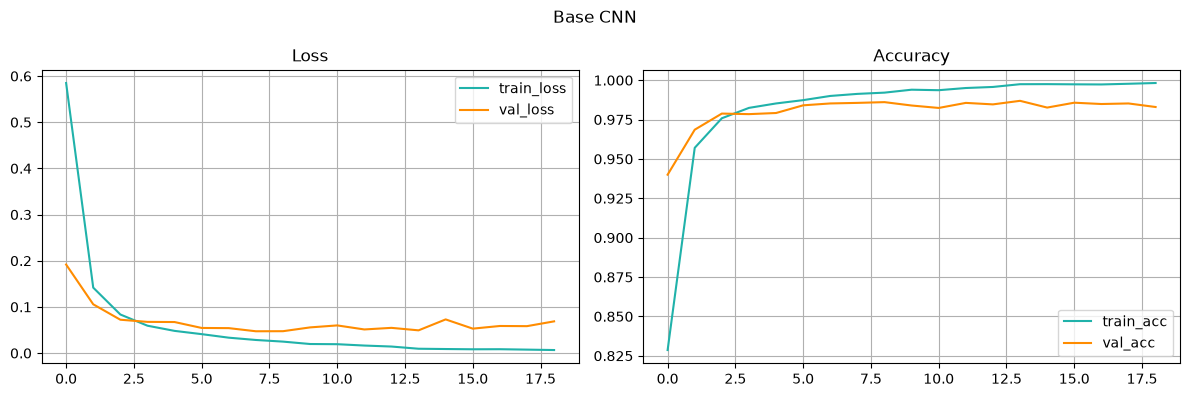

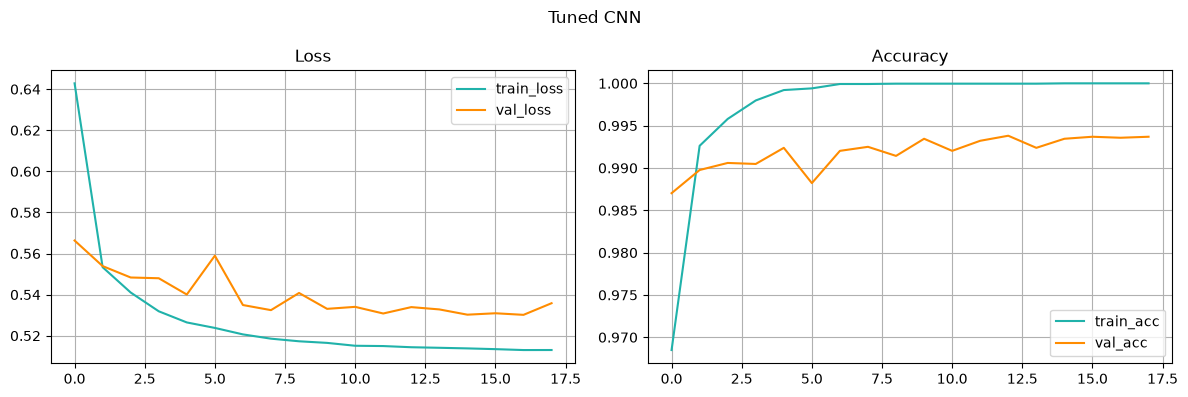

In [25]:
plot_csv_logger(f"{base_cnn_log_dir}/metrics.csv", "Base CNN")
plot_csv_logger(f"{tuned_cnn_log_dir}/metrics.csv", "Tuned CNN")

*Note that the tuned CNN's plot looks noisy / bumpy but this is only due to the zoomed in scaling (only 0.005 - 0.02 difference between y-tick labels)*
* Similar to MLP's tuning vs base model, tuning CNN introduced substantial loss possibly due to regularization settings. There is room for improvement here to lessen loss since tuning increased loss range by about 0.4 (went from 0.1 to 0.5s)
* **Much higher accuracy overall when tuning: going from .97 accuracy range to staying strictly in the .99 range**

## 🏆️ 3. Model Results

### 3.1 All Models Comparison

In [26]:
for model, acc in sorted(scores.items(), key=lambda x: x[1], reverse=True):
    print(f"{model:<25} {acc:.4f}")

Tuned CNN                 0.9938
CNN Baseline              0.9830
Tuned MLP                 0.9807
Base MLP                  0.9657
Log Regression            0.9142


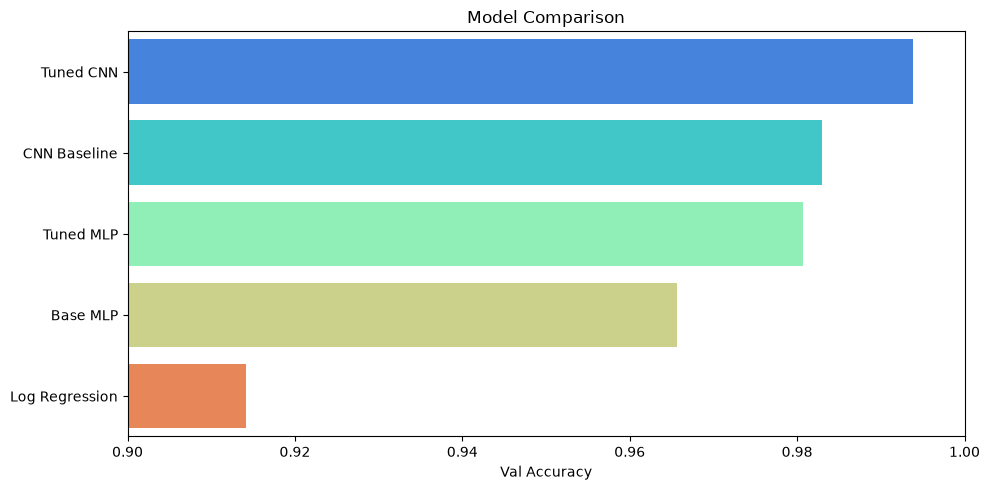

In [27]:
sorted_scores = dict(sorted(scores.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(10, 5))
sns.barplot(
    x=list(sorted_scores.values()),
    y=list(sorted_scores.keys()),
    orient="h",
    hue=list(sorted_scores.keys()),
    palette="rainbow",
)
plt.xlim(0.90, 1.0)
plt.xlabel("Val Accuracy")
plt.title("Model Comparison")
plt.tight_layout()
plt.show()

* All models perform generally well, **all results are >0.91** and show continuous improvement; as we can see in the boundaries and progression of the plot.
 
* It is a big advancement going from Logistic Regression to Deep Learning: this shows the biggest improvement gap between the models.
 
* Tuning always helps the model's accuracy.

* **🏆️ Best model: Tuned CNN with a best epoch val accuracy of 0.9942 / 99.4%**

### 3.2 Evaluating Best Model

#### Test Accuracy

In [28]:
cnn_test = cnn_tuned_trainer.test(cnn_tuned_model, cnn_tuned_dm)
print(f"Tuned CNN test_acc : {round(cnn_test[0]['test_acc'], 4)}")
scores["Tuned CNN test"] = round(cnn_test[0]["test_acc"], 4)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


c:\Users\giddy\Desktop\Turing\computer-vision-mnist\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:429: Consider setting `persistent_workers=True` in 'test_dataloader' to speed up the dataloader worker initialization.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.9952380657196045
        test_loss            0.531377911567688
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Tuned CNN test_acc : 0.9952


Our test accuracy is ~0.995, only 0.005 away from 100% accuracy

#### Classification Report

In [29]:
device = next(cnn_tuned_model.parameters()).device

all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in cnn_tuned_dm.test_dataloader():
        all_preds.append(cnn_tuned_model(x.to(device)).argmax(1).cpu())
        all_labels.append(y)

preds = torch.cat(all_preds).numpy()
labels = torch.cat(all_labels).numpy()
print(classification_report(labels, preds, digits=4))

              precision    recall  f1-score   support

           0     0.9964    0.9976    0.9970       826
           1     0.9968    0.9968    0.9968       937
           2     0.9928    0.9940    0.9934       835
           3     1.0000    0.9966    0.9983       870
           4     0.9903    0.9975    0.9939       815
           5     0.9947    0.9947    0.9947       759
           6     0.9976    0.9952    0.9964       828
           7     0.9966    0.9920    0.9943       880
           8     0.9902    0.9951    0.9926       813
           9     0.9904    0.9869    0.9886       837

    accuracy                         0.9946      8400
   macro avg     0.9946    0.9946    0.9946      8400
weighted avg     0.9947    0.9946    0.9946      8400



Average of all scores - precision, recall, and F1 score - lay around 99.40%, showing good balance and reliability across all 10 digits.

#### Confusion Matrix

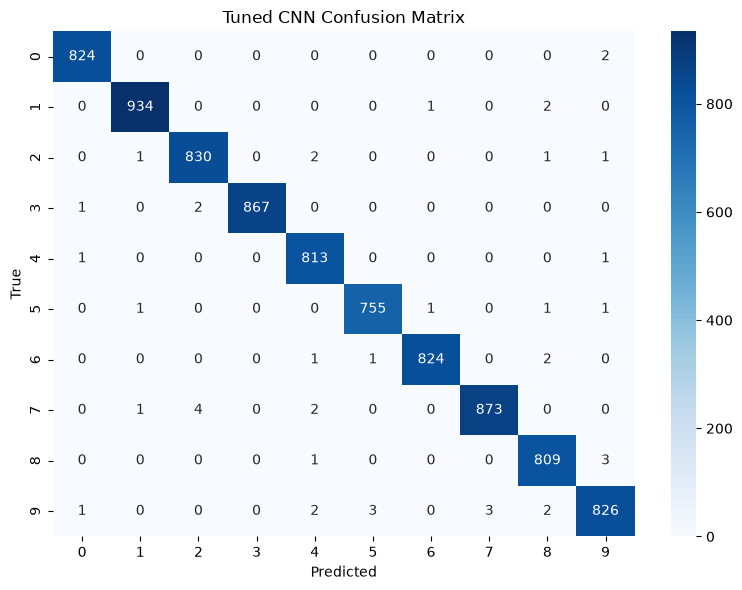

In [30]:
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Tuned CNN Confusion Matrix")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

The model shows strong and solid performance to stick to the center diagonal of correct predictions with sparse misclassifications outside it.

### 3.3 Sample Predictions

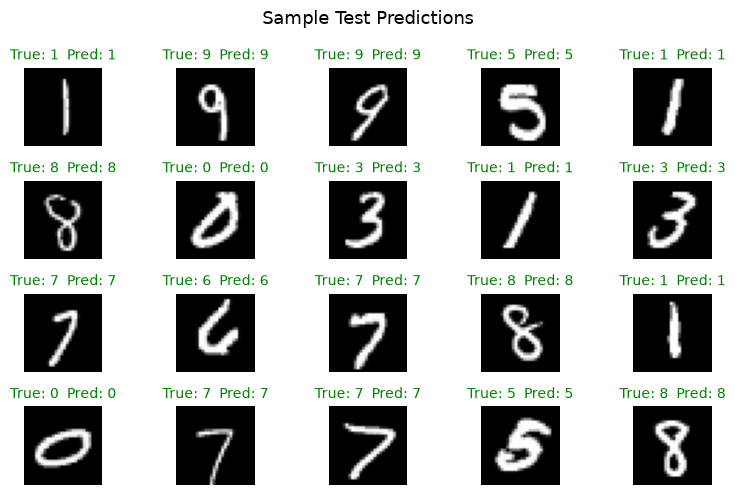

In [31]:
x_batch, y_batch = next(iter(cnn_tuned_dm.test_dataloader()))
sample_preds = cnn_tuned_model(x_batch.to(device)).argmax(1).cpu()

fig, axes = plt.subplots(4, 5, figsize=(8, 5))
for i, ax in enumerate(axes.flatten()):
    img = x_batch[i].numpy().reshape(28, 28)
    true = y_batch[i].item()
    pred = sample_preds[i].item()
    color = "green" if true == pred else "red"
    ax.imshow(img, cmap="gray")
    ax.set_title(f"True: {true}  Pred: {pred}", color=color, fontsize=10)
    ax.axis("off")

plt.suptitle("Sample Test Predictions", fontsize=13)
plt.tight_layout()
plt.show()

From our mini-batch of samples, the tuned CNN model predicted each digit correctly.

## 4. Conclusion
#### Suggestions for Improvement / Next Steps:
* Adjust hyperparameters accordingly to other parameters around it (e.g. decrease learning rates when using specific optimizers, changing dropout when changing BatchNorm)
* Experiment with *data augmentation*, ***learning rate scheduling*** and other techniques
* Experiment with other pretrained models / more CNN architecture
### Key Findings:
* From classification with **Logistic Regression to Deep Learning, neural networks display an advantageous gap in performance** - among our models it is actually the biggest improvement gap going from ~91% accuracy to ~97%
* **Tuning hyperparamaters was always beneficial** for the neural networks to have much better accuracy.
* All 5 models' best epoch validation scores are:
    1. **Tuned CNN - 0.9942**
    2. CNN Baseline - 0.9850
    3. Tuned MLP - 0.9805
    4. Base MLP - 0.9663
    5. Log Regression - 0.9137
* 🏆️ The **best model is a tuned CNN model achieving 99.4% accuracy** on the test set.